<a href="https://colab.research.google.com/github/humbeaniket2006-max/Brand_Ad_Video_Analyzer/blob/main/Brand_Ad_Video_Analyzer_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 Brand Ad Video Analyzer
> **PineOS** — Analyze any brand's ad video for tone, messaging, and brand consistency

**How it works:**
1. Upload any brand ad video (MP4)
2. OpenCV extracts frames every N seconds
3. Gemini Vision analyzes each frame
4. Outputs brand tone, products visible, on-brand score, and full JSON report

**Stack:** Python · OpenCV · Gemini 2.0 Flash Lite Vision  
**Built by:** Aniket Humbe

---

In [ ]:
# @title ⚙️ Cell 1 — Install Dependencies (run once)
!pip install -q opencv-python-headless google-genai
print("✅ Dependencies installed.")

✅ Dependencies installed.


In [ ]:
# @title 🔑 Cell 2 — Load Gemini API Key from Colab Secrets
from google.colab import userdata

try:
    GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
    if not GEMINI_API_KEY:
        raise KeyError
    print("✅ Gemini API key loaded from Colab Secrets.")
except Exception:
    import getpass
    GEMINI_API_KEY = getpass.getpass("Paste your Gemini API key: ")
    print("✅ API key set manually.")

✅ Gemini API key loaded from Colab Secrets.


In [ ]:
# @title 🔧 Cell 3 — Load All Functions (run once)
import cv2
import base64
import json
import time
import os
import re
from google import genai
from IPython.display import display, Image as IPImage, JSON
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from io import BytesIO
import numpy as np

# ── Config ────────────────────────────────────────────────────────────────────
GEMINI_MODEL       = "gemini-2.0-flash-lite"
GEMINI_RPM_DELAY   = 4.5   # seconds between API calls
MAX_RETRIES        = 4
BACKOFF_BASE       = 10    # seconds, doubles each retry

# ── Frame Extraction ─────────────────────────────────────────────────────────
def extract_frames(video_path, every_n_seconds=2):
    """
    Extract frames from a video every N seconds.
    Returns list of (frame_index, timestamp, base64_jpeg, numpy_frame)
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    fps         = cap.get(cv2.CAP_PROP_FPS)
    total_frames= int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration    = total_frames / fps
    interval    = int(fps * every_n_seconds)

    print(f"  📹 Video info: {duration:.1f}s duration, {fps:.0f} FPS, {total_frames} total frames")
    print(f"  🖼️  Extracting 1 frame every {every_n_seconds}s (interval: {interval} frames)")

    frames = []
    frame_count = 0
    extracted = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if frame_count % interval == 0:
            timestamp = frame_count / fps
            _, buffer = cv2.imencode('.jpg', frame, [cv2.IMWRITE_JPEG_QUALITY, 85])
            b64 = base64.b64encode(buffer).decode()
            frames.append({
                "index":     extracted,
                "timestamp": round(timestamp, 1),
                "b64":       b64,
                "frame":     frame  # numpy array for display
            })
            extracted += 1
        frame_count += 1

    cap.release()
    print(f"  ✅ Extracted {len(frames)} frames")
    return frames


# ── Gemini retry wrapper ──────────────────────────────────────────────────────
def call_gemini(client, contents):
    """Call Gemini with exponential backoff on rate limits."""
    for attempt in range(MAX_RETRIES):
        try:
            time.sleep(GEMINI_RPM_DELAY)
            response = client.models.generate_content(
                model=GEMINI_MODEL,
                contents=contents
            )
            return response.text.strip()
        except Exception as e:
            err = str(e).lower()
            if any(x in err for x in ["429", "quota", "rate", "resource_exhausted"]):
                wait = BACKOFF_BASE * (2 ** attempt)
                print(f"  ⏳ Rate limit — waiting {wait}s (attempt {attempt+1}/{MAX_RETRIES})")
                time.sleep(wait)
            else:
                raise
    raise RuntimeError(f"Rate limit persisted after {MAX_RETRIES} retries.")


def parse_json(raw):
    """Strip markdown fences and parse JSON."""
    raw = re.sub(r'^```(?:json)?\s*', '', raw)
    raw = re.sub(r'\s*```$', '', raw)
    return json.loads(raw.strip())


# ── Per-frame analysis prompt ─────────────────────────────────────────────────
FRAME_PROMPT = """
You are a brand intelligence analyst analyzing a frame from a brand advertisement video.

Analyze this frame and return ONLY valid JSON — no markdown, no commentary:
{{
  "timestamp_s": {timestamp},
  "products_visible": ["list of products or product categories visible"],
  "text_on_screen": "any text/tagline visible in the frame",
  "dominant_colors": ["2-3 main colors"],
  "tone": "one word: playful/premium/clinical/energetic/emotional/aspirational",
  "scene_description": "one sentence describing what's happening",
  "on_brand_score": 0,
  "notes": "any key observation about brand messaging"
}}

on_brand_score: rate 1-10 how professional and brand-consistent this frame looks.
Brand context: {brand_name}
"""

# ── Merge/summary prompt ──────────────────────────────────────────────────────
SUMMARY_PROMPT = """
You are a brand intelligence analyst. I've analyzed {n_frames} frames from a {brand_name} ad video.
Here are the per-frame results:

{frame_results}

Synthesize into a final brand video intelligence report. Return ONLY valid JSON:
{{
  "brand": "{brand_name}",
  "video_duration_analyzed": "{duration}s",
  "frames_analyzed": {n_frames},
  "overall_tone": ["2-3 adjectives"],
  "products_featured": ["deduplicated list"],
  "key_messages": ["main messages/taglines spotted"],
  "dominant_colors": ["brand color palette from video"],
  "avg_on_brand_score": 0.0,
  "consistency_score": 0,
  "brand_persona_summary": "2-3 sentence summary of how this brand presents itself in video",
  "recommendations": ["1-2 suggestions for brand intelligence pipeline"]
}}

consistency_score: 1-10, how consistent the brand identity is across all frames.
"""


# ── Main analyzer ─────────────────────────────────────────────────────────────
def analyze_brand_video(video_path, brand_name, api_key,
                         every_n_seconds=2, max_frames=10):
    """
    Full pipeline: video → frames → Gemini Vision → brand intelligence report.

    Args:
        video_path:      Path to MP4 file
        brand_name:      Brand name for context (e.g. 'Mamaearth')
        api_key:         Gemini API key
        every_n_seconds: Frame extraction interval
        max_frames:      Max frames to analyze (keep ≤10 for free tier)

    Returns:
        dict with full report
    """
    client = genai.Client(api_key=api_key)

    print(f"\n🎬 Analyzing: {brand_name} ad video")
    print(f"{'─'*50}")

    # Step 1: Extract frames
    all_frames = extract_frames(video_path, every_n_seconds)
    frames     = all_frames[:max_frames]  # cap for rate limits
    if len(all_frames) > max_frames:
        print(f"  ⚠️  Capped at {max_frames} frames (rate limit safety)")

    # Step 2: Analyze each frame with Gemini Vision
    print(f"\n  🤖 Analyzing {len(frames)} frames with Gemini Vision...")
    frame_results = []

    for f in frames:
        print(f"  → Frame {f['index']+1}/{len(frames)} @ {f['timestamp']}s")
        prompt = FRAME_PROMPT.format(
            timestamp=f['timestamp'],
            brand_name=brand_name
        )
        contents = [
            {
                "parts": [
                    {"inline_data": {"mime_type": "image/jpeg", "data": f['b64']}},
                    {"text": prompt}
                ]
            }
        ]
        try:
            raw    = call_gemini(client, contents)
            result = parse_json(raw)
            frame_results.append(result)
        except json.JSONDecodeError:
            print(f"    [warn] Non-JSON response — skipping frame.")
        except Exception as e:
            print(f"    [warn] {e} — skipping frame.")

    if not frame_results:
        raise RuntimeError("No frames were analyzed successfully.")

    # Step 3: Merge into final report
    print(f"\n  🔀 Generating final brand intelligence report...")
    duration_analyzed = frames[-1]['timestamp'] if frames else 0
    merge_prompt = SUMMARY_PROMPT.format(
        brand_name=brand_name,
        n_frames=len(frame_results),
        duration=duration_analyzed,
        frame_results=json.dumps(frame_results, indent=2)[:6000]
    )
    try:
        raw    = call_gemini(client, merge_prompt)
        report = parse_json(raw)
    except Exception as e:
        print(f"  [warn] Summary failed: {e}. Returning raw frame results.")
        report = {"brand": brand_name, "frame_analysis": frame_results}

    report["frame_analysis"] = frame_results
    report["model_used"]     = GEMINI_MODEL
    return report, frames


# ── Display helpers ───────────────────────────────────────────────────────────
def show_frames_grid(frames, max_show=6):
    """Display extracted frames in a grid."""
    show = frames[:max_show]
    cols = 3
    rows = (len(show) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()
    for i, f in enumerate(show):
        rgb = cv2.cvtColor(f['frame'], cv2.COLOR_BGR2RGB)
        axes[i].imshow(rgb)
        axes[i].set_title(f"Frame {f['index']+1} @ {f['timestamp']}s", fontsize=10)
        axes[i].axis('off')
    for j in range(len(show), len(axes)):
        axes[j].axis('off')
    plt.suptitle('Extracted Frames', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def print_report_summary(report):
    """Pretty print the final report."""
    sep = '─' * 55
    print(f"\n{sep}")
    print(f"  ✅ Brand Video Intelligence Report — {report.get('brand', 'Unknown')}")
    print(sep)
    print(f"  Frames analyzed    : {report.get('frames_analyzed', '?')}")
    print(f"  Duration analyzed  : {report.get('video_duration_analyzed', '?')}")
    print(f"  Overall tone       : {', '.join(report.get('overall_tone') or [])}")
    print(f"  Products featured  : {', '.join(report.get('products_featured') or [])}")
    print(f"  Key messages       : {', '.join(report.get('key_messages') or [])}")
    print(f"  Avg on-brand score : {report.get('avg_on_brand_score', '?')} / 10")
    print(f"  Consistency score  : {report.get('consistency_score', '?')} / 10")
    print(f"  Model used         : {report.get('model_used', '?')}")
    print(sep)
    if report.get('brand_persona_summary'):
        print(f"\n  📝 Brand Persona:")
        print(f"  {report['brand_persona_summary']}")
    if report.get('recommendations'):
        print(f"\n  💡 Recommendations:")
        for r in report['recommendations']:
            print(f"  • {r}")
    print(f"{sep}\n")


print("✅ All functions loaded. Proceed to Cell 4.")

✅ All functions loaded. Proceed to Cell 4.


📁 Upload your brand ad video (MP4)...


Saving YTDown.com_YouTube_Get-Your-Skin-Summer-Ready-Mamaearth-Ubt_Media_BT6DO4UyWqg_002_720p.mp4 to YTDown.com_YouTube_Get-Your-Skin-Summer-Ready-Mamaearth-Ubt_Media_BT6DO4UyWqg_002_720p.mp4

✅ Uploaded: YTDown.com_YouTube_Get-Your-Skin-Summer-Ready-Mamaearth-Ubt_Media_BT6DO4UyWqg_002_720p.mp4 (2.0 MB)

🖼️  Extracting frames preview...
  📹 Video info: 19.4s duration, 25 FPS, 485 total frames
  🖼️  Extracting 1 frame every 2s (interval: 50 frames)
  ✅ Extracted 10 frames


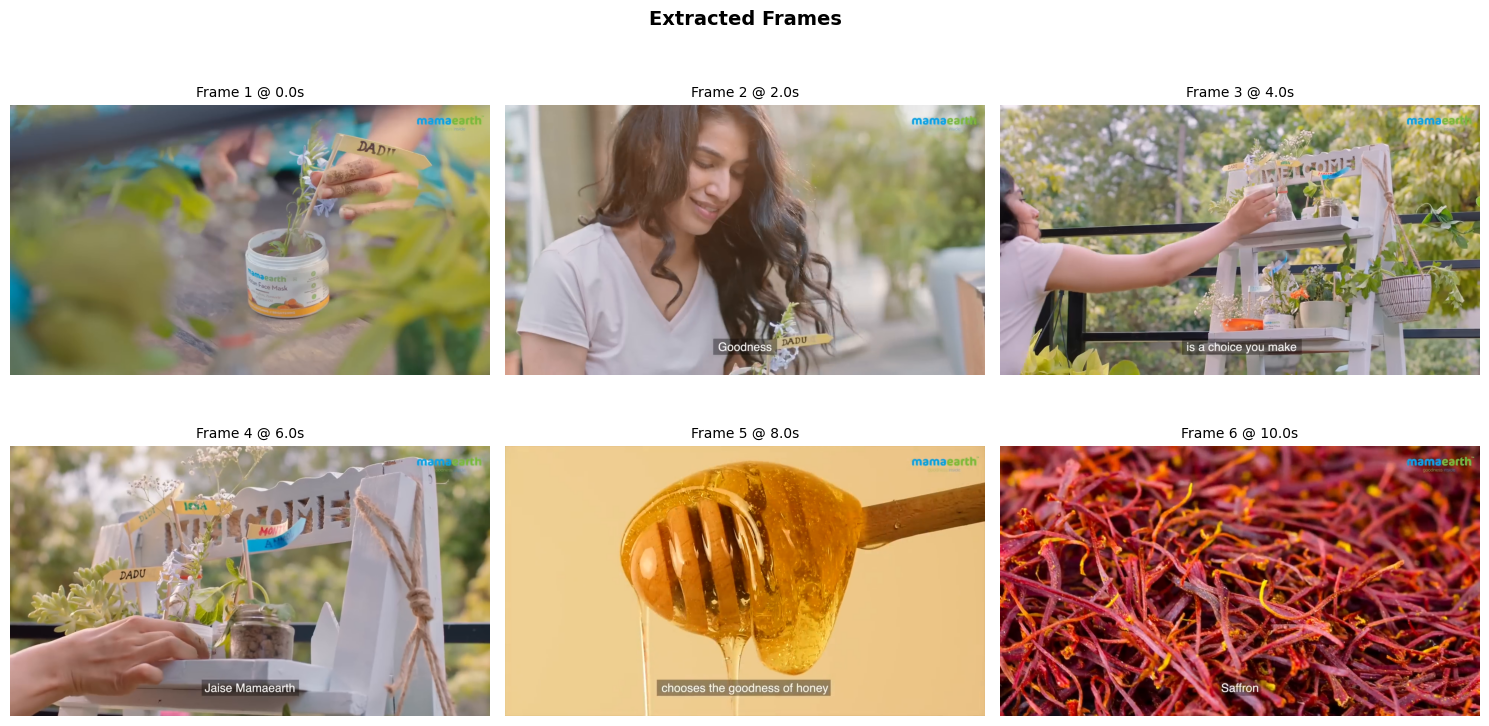


🎬 Analyzing: Mamaearth ad video
──────────────────────────────────────────────────
  📹 Video info: 19.4s duration, 25 FPS, 485 total frames
  🖼️  Extracting 1 frame every 2s (interval: 50 frames)
  ✅ Extracted 10 frames
  ⚠️  Capped at 8 frames (rate limit safety)

  🤖 Analyzing 8 frames with Gemini Vision...
  → Frame 1/8 @ 0.0s
  ⏳ Rate limit — waiting 10s (attempt 1/4)
  ⏳ Rate limit — waiting 20s (attempt 2/4)
  ⏳ Rate limit — waiting 40s (attempt 3/4)
  ⏳ Rate limit — waiting 80s (attempt 4/4)
    [warn] Rate limit persisted after 4 retries. — skipping frame.
  → Frame 2/8 @ 2.0s
  ⏳ Rate limit — waiting 10s (attempt 1/4)
  ⏳ Rate limit — waiting 20s (attempt 2/4)
  ⏳ Rate limit — waiting 40s (attempt 3/4)
  ⏳ Rate limit — waiting 80s (attempt 4/4)
    [warn] Rate limit persisted after 4 retries. — skipping frame.
  → Frame 3/8 @ 4.0s
  ⏳ Rate limit — waiting 10s (attempt 1/4)
  ⏳ Rate limit — waiting 20s (attempt 2/4)
  ⏳ Rate limit — waiting 40s (attempt 3/4)
  ⏳ Rate limit — w

RuntimeError: No frames were analyzed successfully.

In [ ]:
# @title 🚀 Cell 4 — Upload Video & Run Analysis

# @markdown ### Settings
BRAND_NAME       = "Mamaearth" # @param {type:"string"}
FRAME_INTERVAL_S = 2           # @param {type:"integer"}
MAX_FRAMES       = 8           # @param {type:"integer"}
SHOW_FRAMES_GRID = True        # @param {type:"boolean"}

from google.colab import files
import os

print("📁 Upload your brand ad video (MP4)...")
uploaded = files.upload()

if not uploaded:
    print("❌ No file uploaded.")
else:
    VIDEO_PATH = list(uploaded.keys())[0]
    print(f"\n✅ Uploaded: {VIDEO_PATH} ({os.path.getsize(VIDEO_PATH)/1024/1024:.1f} MB)")

    # Show frames grid first
    if SHOW_FRAMES_GRID:
        print("\n🖼️  Extracting frames preview...")
        preview_frames = extract_frames(VIDEO_PATH, FRAME_INTERVAL_S)
        show_frames_grid(preview_frames)

    # Run full analysis
    REPORT, FRAMES = analyze_brand_video(
        video_path      = VIDEO_PATH,
        brand_name      = BRAND_NAME,
        api_key         = GEMINI_API_KEY,
        every_n_seconds = FRAME_INTERVAL_S,
        max_frames      = MAX_FRAMES
    )

    # Print summary
    print_report_summary(REPORT)

In [ ]:
# @title 👁️ Cell 5 — View Full JSON Report
import json
print(json.dumps(REPORT, indent=2, ensure_ascii=False))

In [ ]:
# @title 🔍 Cell 6 — View Per-Frame Analysis with Images
import json

for i, (frame_data, analysis) in enumerate(zip(FRAMES[:len(REPORT['frame_analysis'])],
                                                REPORT['frame_analysis'])):
    print(f"\n{'='*50}")
    print(f"  Frame {i+1} @ {frame_data['timestamp']}s")
    print('='*50)

    # Show frame
    rgb = cv2.cvtColor(frame_data['frame'], cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6, 3))
    plt.imshow(rgb)
    plt.axis('off')
    plt.title(f"Frame {i+1} @ {frame_data['timestamp']}s")
    plt.show()

    # Show analysis
    print(f"  Tone            : {analysis.get('tone', 'N/A')}")
    print(f"  Products visible: {', '.join(analysis.get('products_visible') or [])}")
    print(f"  Text on screen  : {analysis.get('text_on_screen', 'N/A')}")
    print(f"  On-brand score  : {analysis.get('on_brand_score', 'N/A')} / 10")
    print(f"  Scene           : {analysis.get('scene_description', 'N/A')}")
    print(f"  Notes           : {analysis.get('notes', 'N/A')}")

In [ ]:
# @title 💾 Cell 7 — Download JSON Report
import json
from google.colab import files

filename = f"{BRAND_NAME.lower().replace(' ', '_')}_video_intelligence.json"
with open(filename, 'w', encoding='utf-8') as f:
    # Remove numpy frames before saving (not JSON serializable)
    save_report = {k: v for k, v in REPORT.items() if k != 'frame_analysis'}
    save_report['frame_analysis'] = REPORT.get('frame_analysis', [])
    json.dump(save_report, f, indent=2, ensure_ascii=False)

print(f"💾 Saved as {filename}")
files.download(filename)
print("✅ Download triggered.")